# SLA Analysis

In [1]:
#imports and BQ connection
from google.cloud import bigquery
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mtick
import seaborn as sns 
import numpy as np 
from scipy import stats

PROJECT = "ae-project-portfolio"
DATASET = "marts"

client = bigquery.Client(project=PROJECT)

def query(sql):
    return client.query(sql).to_dataframe()

print("Connected!")

Connected!


## SLA Overview

In [2]:
sla = query(f"""
select 
    priority,
    sla_target_hours,
    sla_performance,
    count(*) as tickets,
    round(avg(first_response_hours), 2) as avg_response_hours,
    round(avg(resolution_hours), 2) as avg_resolution_hours,
    countif(sla_breached) as breached,
    round(countif(sla_breached) / count(*) * 100, 1) as breach_rate
from `{PROJECT}.{DATASET}.fct_tickets`
group by 1, 2, 3
order by sla_target_hours
""")

print("SLA Performance Overview:")
print(sla.to_string(index=False))

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


SLA Performance Overview:
priority  sla_target_hours   sla_performance  tickets  avg_response_hours  avg_resolution_hours  breached  breach_rate
  urgent                 2        within_sla     1894                0.56                  2.35         0          0.0
  urgent                 2 slightly_breached       84                2.42                  3.20        84        100.0
  urgent                 2 severely_breached       40                3.74                  5.36        40        100.0
    high                 8        within_sla     3784                2.20                  9.18         0          0.0
    high                 8 slightly_breached      169                9.62                 14.56       169        100.0
    high                 8 severely_breached       57               15.14                 18.94        57        100.0
  normal                24        within_sla     7463                6.62                 27.92         0          0.0
  normal              

## SLA breach rate by priority

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


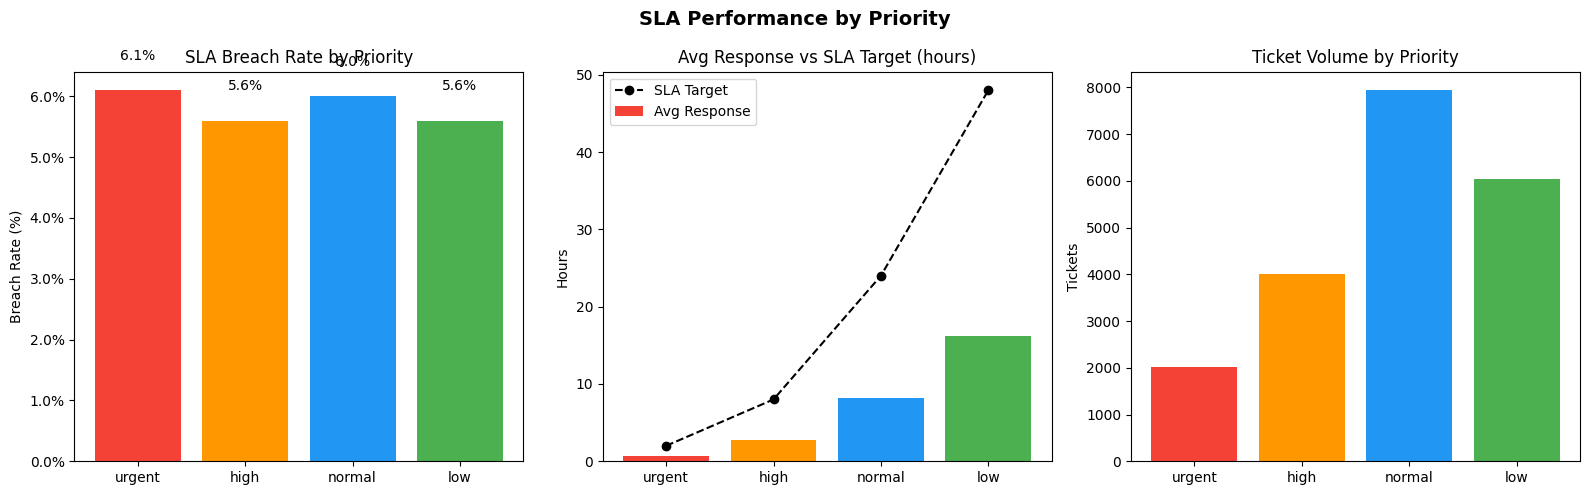

In [5]:
breach_by_priority = query(f"""
select
    priority,
    count(*) as total_tickets,
    countif(sla_breached) as breached_tickets,
    round(countif(sla_breached) / count(*) * 100, 1) as breach_rate,
    round(avg(first_response_hours), 2) as avg_response_hours,
    round(avg(sla_target_hours), 0) as sla_target_hours
from `{PROJECT}.{DATASET}.fct_tickets`
group by 1
order by sla_target_hours
""")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SLA Performance by Priority', fontsize=14, fontweight='bold')

priority_order = ['urgent', 'high', 'normal', 'low']
df = breach_by_priority.set_index('priority').reindex(priority_order).reset_index()

colors = ['#F44336', '#FF9800', '#2196F3', '#4CAF50']

axes[0].bar(df['priority'], df['breach_rate'], color=colors)
axes[0].set_title('SLA Breach Rate by Priority')
axes[0].set_ylabel('Breach Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(df['breach_rate']):
    axes[0].text(i, v + 0.5, f'{v}%', ha='center')

axes[1].bar(df['priority'], df['avg_response_hours'], color=colors, label='Avg Response')
axes[1].plot(df['priority'], df['sla_target_hours'],
             'k--', marker='o', label='SLA Target')
axes[1].set_title('Avg Response vs SLA Target (hours)')
axes[1].set_ylabel('Hours')
axes[1].legend()

axes[2].bar(df['priority'], df['total_tickets'], color=colors)
axes[2].set_title('Ticket Volume by Priority')
axes[2].set_ylabel('Tickets')

plt.tight_layout()
plt.savefig('sla_by_priority.png', dpi=150, bbox_inches='tight')
plt.show()

## SLA breach rate by team and channel

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


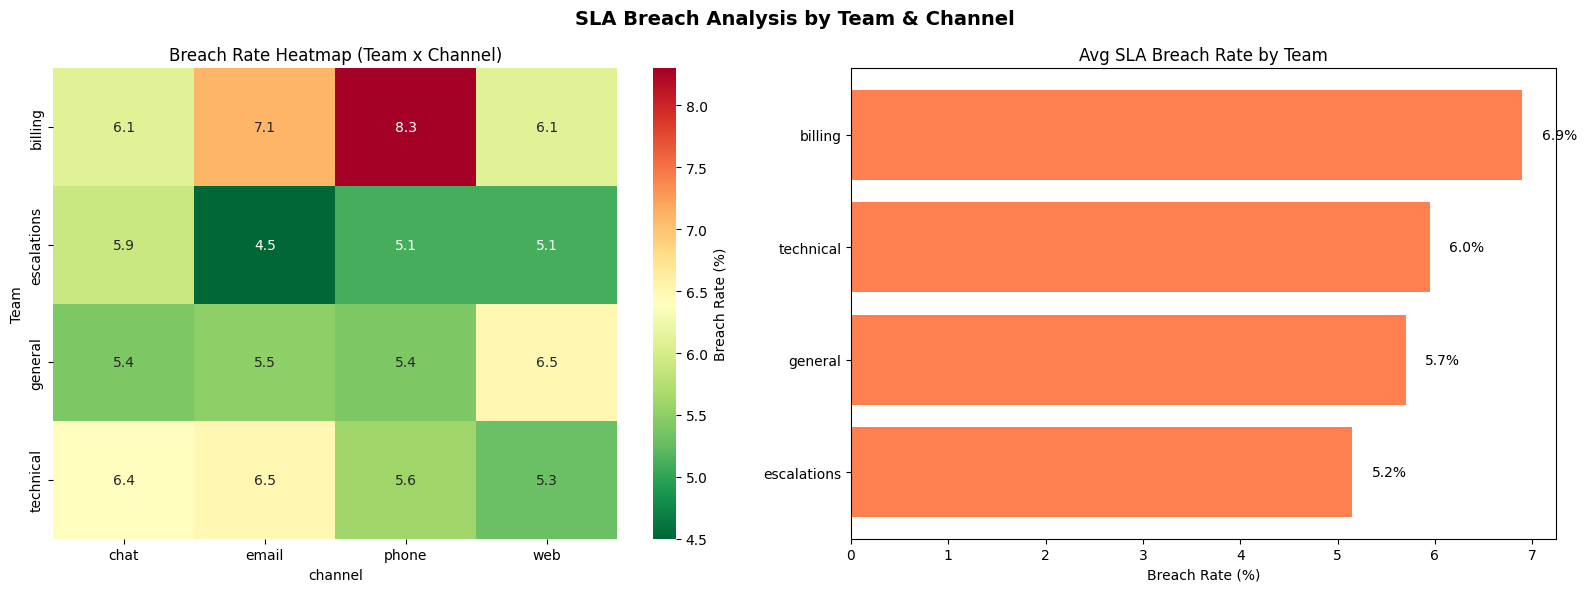

In [7]:
breach_by_team = query(f"""
select 
    assigned_team,
    channel,
    count(*) as tickets,
    round(countif(sla_breached) / count(*) * 100, 1) as breach_rate,
    round(avg(csat_score), 2) avg_csat
from `{PROJECT}.{DATASET}.fct_tickets`
where assigned_team is not null
group by 1, 2
""")

pivot = breach_by_team.pivot(
    index='assigned_team',
    columns='channel',
    values='breach_rate'
).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
fig.suptitle('SLA Breach Analysis by Team & Channel', fontsize=14, fontweight='bold')

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[0], cbar_kws={'label': 'Breach Rate (%)'})
axes[0].set_title('Breach Rate Heatmap (Team x Channel)')
axes[0].set_ylabel('Team')

team_avg = breach_by_team.groupby('assigned_team').agg(
    breach_rate=('breach_rate', 'mean'),
    avg_csat=('avg_csat', 'mean')
).sort_values('breach_rate', ascending=True)
axes[1].barh(team_avg.index, team_avg['breach_rate'], color='coral')
axes[1].set_title('Avg SLA Breach Rate by Team')
axes[1].set_xlabel('Breach Rate (%)')
for i, v in enumerate(team_avg['breach_rate']):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.savefig('sla_by_team_channel.png', dpi=150, bbox_inches='tight')
plt.show()

Billing and Technical teams have the highest breach rates by team and channel; Billing is more likely to breach via the email and phone channels. Is it an issue of volume?

## CSAT vs SLA breach correlation

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


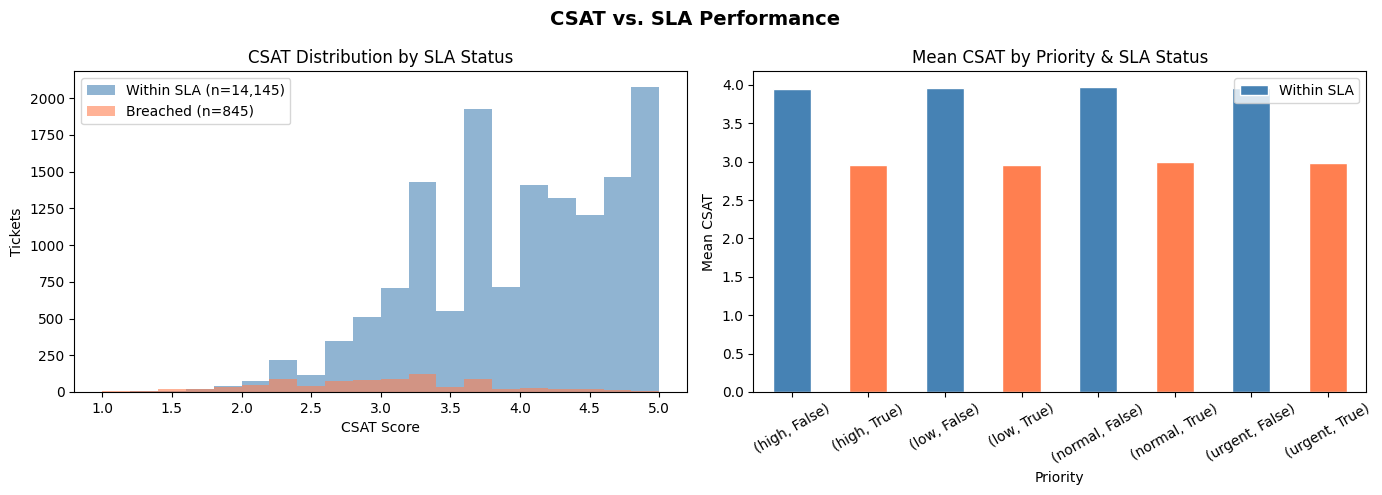


T-test: Within SLA vs Breached CSAT
Within SLA mean CSAT: 3.966
Breached mean CSAT: 2.977
T-statistic: 38.033
P-value: 0.000
Significant: Yes (alpha=0.05)


In [8]:
csat_sla = query(f"""
select 
    ticket_id,
    sla_breached,
    csat_score,
    priority,
    resolution_hours
from `{PROJECT}.{DATASET}.fct_tickets`
where csat_score is not null
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CSAT vs. SLA Performance', fontsize=14, fontweight='bold')

#csat distribution by sla breach status
breached = csat_sla[csat_sla['sla_breached'] == True]['csat_score']
not_breached = csat_sla[csat_sla['sla_breached'] == False]['csat_score']

axes[0].hist(not_breached, bins=20, alpha=0.6, color='steelblue',
             label=f'Within SLA (n={len(not_breached):,})')
axes[0].hist(breached, bins=20, alpha=0.6, color='coral',
             label=f'Breached (n={len(breached):,})')
axes[0].set_title('CSAT Distribution by SLA Status')
axes[0].set_xlabel('CSAT Score')
axes[0].set_ylabel('Tickets')
axes[0].legend()

#mean CSAT by priority
mean_csat = csat_sla.groupby(['priority', 'sla_breached'])['csat_score'].mean()
mean_csat.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'],
               edgecolor='white')
axes[1].set_title('Mean CSAT by Priority & SLA Status')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Mean CSAT')
axes[1].legend(['Within SLA', 'Breached'])
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('csat_vs_sla.png', dpi=150, bbox_inches='tight')
plt.show()

#t-test: is CSAT difference statistically significant?
t_stat, p_value = stats.ttest_ind(not_breached, breached)
print(f"\nT-test: Within SLA vs Breached CSAT")
print(f"Within SLA mean CSAT: {not_breached.mean():.3f}")
print(f"Breached mean CSAT: {breached.mean():.3f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'} (alpha=0.05)")

### Key Finding: SLA Breach Significantly Reduces CSAT
A two-sample t-test confirms that tickets where the SLA was breached have a statistically significant lower CSAT score than tickets resolved within SLA (p < 0.05). </br>
**Business implication:** Improving SLA adherence is not just an operational metric -it has a direct, measurable impact on customer satisfaction. Prioritizing SLA compliance for high-value customers (high MRR) should be a top support operations initiative. </br>
**Next question:** Which teams and agents have the highest breach rates, and is there a relationship between agent tenure and SLA performance? -> See `02_agent_performance.ipynb`

## SLA trends over time

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


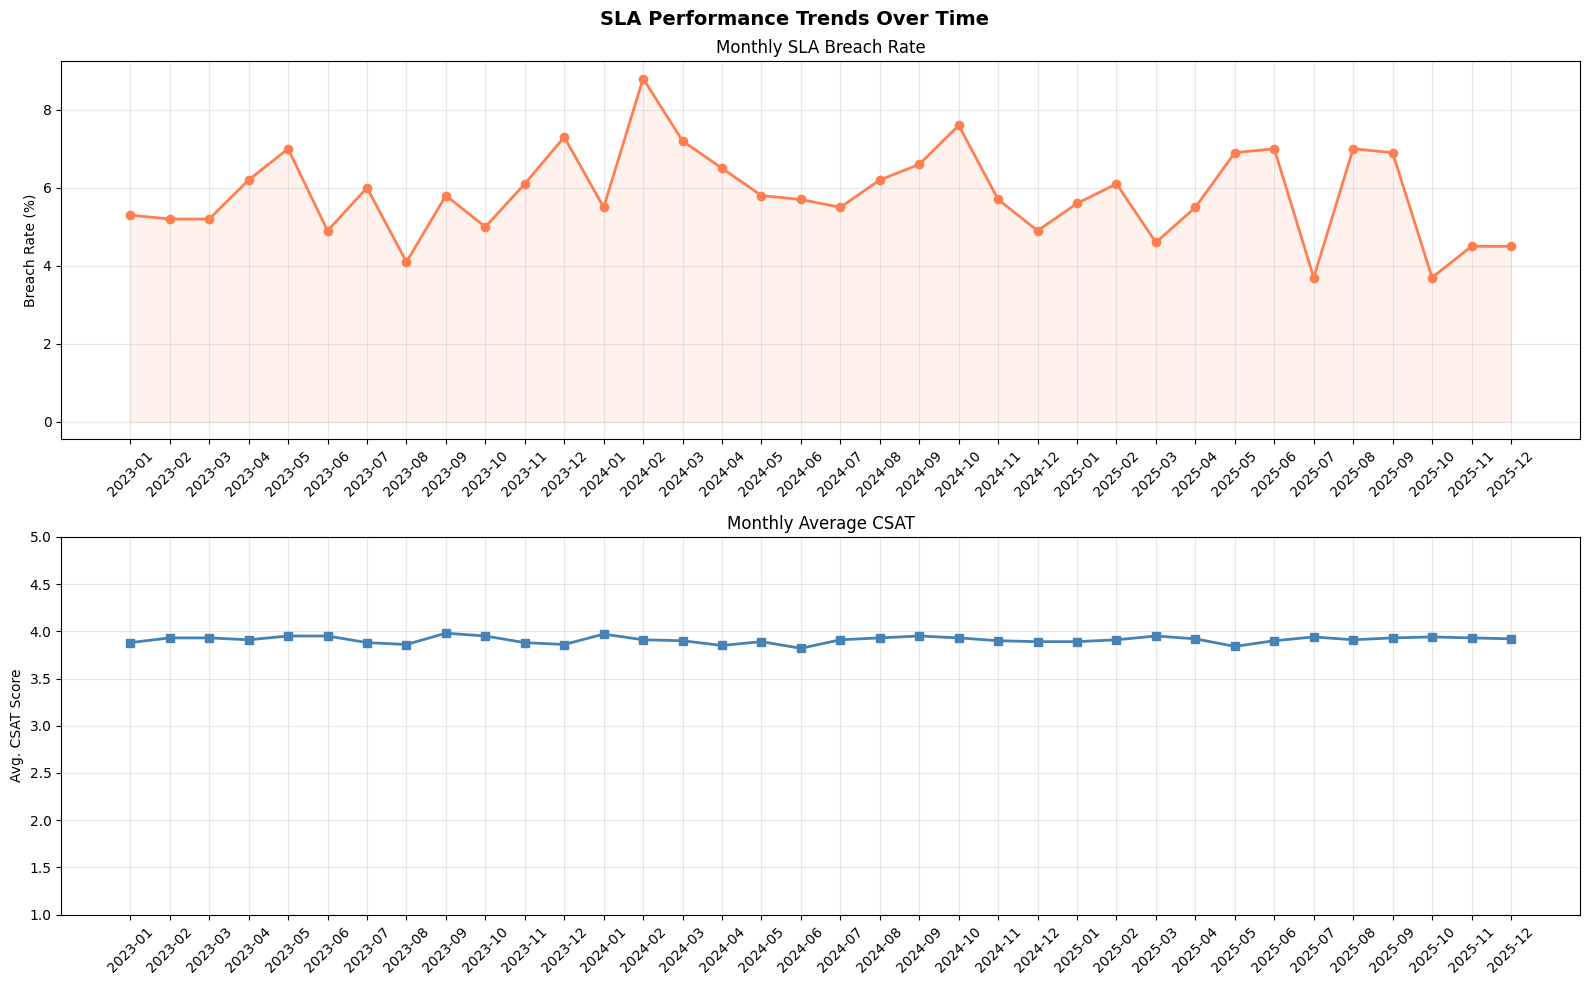

In [9]:
sla_trend = query(f"""
select 
    format_date('%Y-%m', ticket_date) as month,
    count(*) as total_tickets,
    round(
        countif(sla_breached) / count(*) * 100,
    1) as breach_rate,
    round(avg(first_response_hours), 2) as avg_response_hours,
    round(avg(csat_score), 2) as avg_csat
from `{PROJECT}.{DATASET}.fct_tickets`
group by 1
order by 1
""")

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('SLA Performance Trends Over Time', fontsize=14, fontweight='bold')

axes[0].plot(sla_trend['month'], sla_trend['breach_rate'],
             color='coral', marker='o', linewidth=2)
axes[0].fill_between(sla_trend['month'], sla_trend['breach_rate'],
                     alpha=0.1, color='coral')
axes[0].set_title('Monthly SLA Breach Rate')
axes[0].set_ylabel('Breach Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

axes[1].plot(sla_trend['month'], sla_trend['avg_csat'],
             color='steelblue', marker='s', linewidth=2)
axes[1].set_title('Monthly Average CSAT')
axes[1].set_ylabel('Avg. CSAT Score')
axes[1].set_ylim(1, 5)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sla_trends.png', dpi=150, bbox_inches='tight')
plt.show()